# WESAD — HRV exploration

Reads the feature table built by `src/prepare.py`. Figures are written to `outputs/`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append("../src")
from features import FEATURES

sns.set_theme(style="whitegrid")
OUTPUTS = Path("../outputs")

df = pd.read_csv("../data/hrv_features.csv")
print(f"{len(df)} windows, {df.subject.nunique()} subjects, {df.stress.mean():.1%} stress")
df.groupby("condition").size()

1396 windows, 15 subjects, 22.3% stress


condition
amusement     165
baseline      565
meditation    355
stress        311
dtype: int64

## Does the data show the expected stress response?

Under stress the heart should speed up and beat-to-beat variability should fall.

In [ ]:
summary = df.groupby("condition")[["mean_hr", "rmssd", "sdnn", "pnn50", "lf_hf_ratio"]].mean().round(1)
summary

,mean_hr,rmssd,sdnn,pnn50,lf_hf_ratio
condition,,,,,
amusement,73.1,49.1,74.7,25.3,5.1
baseline,73.0,49.6,68.0,26.9,2.9
meditation,70.0,66.5,94.0,32.4,5.7
stress,98.7,31.7,57.1,13.2,4.5


## Feature distributions, stress vs rest

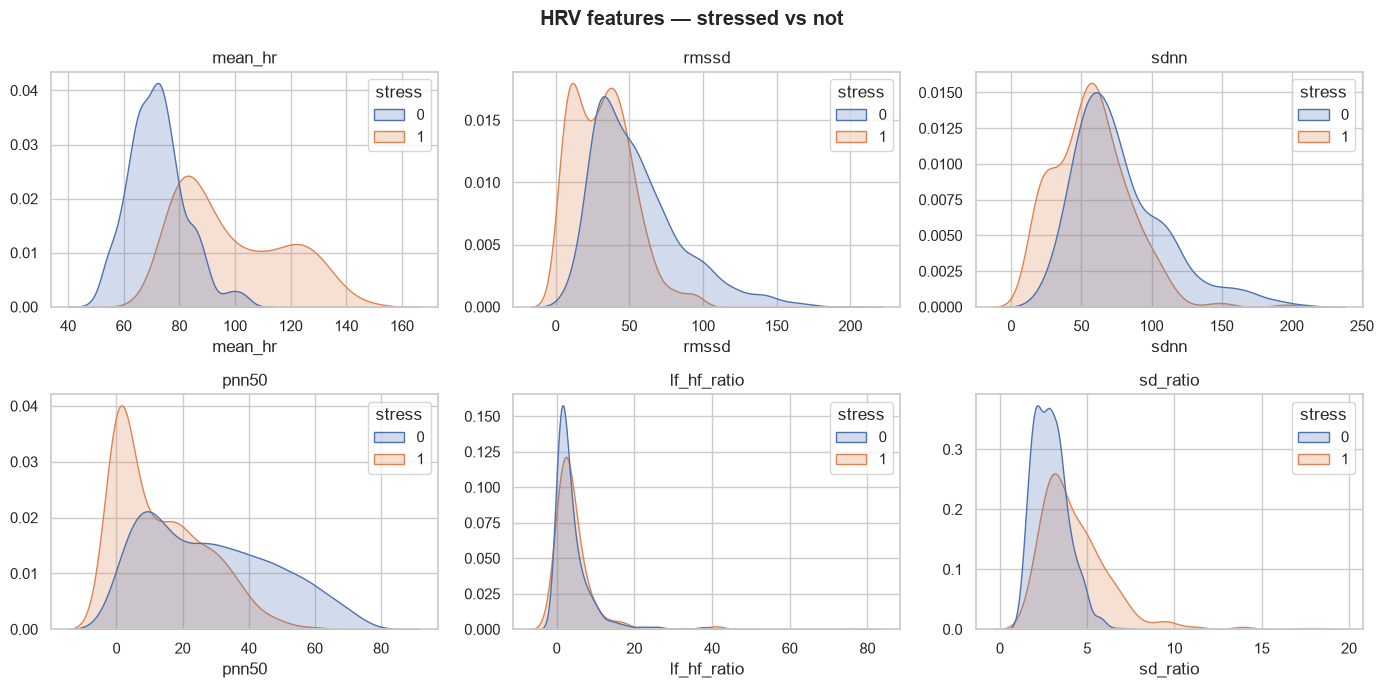

In [3]:
key = ["mean_hr", "rmssd", "sdnn", "pnn50", "lf_hf_ratio", "sd_ratio"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feature in zip(axes.ravel(), key):
    sns.kdeplot(data=df, x=feature, hue="stress", fill=True, common_norm=False, ax=ax)
    ax.set_title(feature)
    ax.set_ylabel("")
fig.suptitle("HRV features — stressed vs not", fontweight="bold")
fig.tight_layout()
fig.savefig(OUTPUTS / "hrv_distributions.png", dpi=150)

## Feature correlation

Related features are expected to cluster; near-duplicates were already dropped in `features.py`.

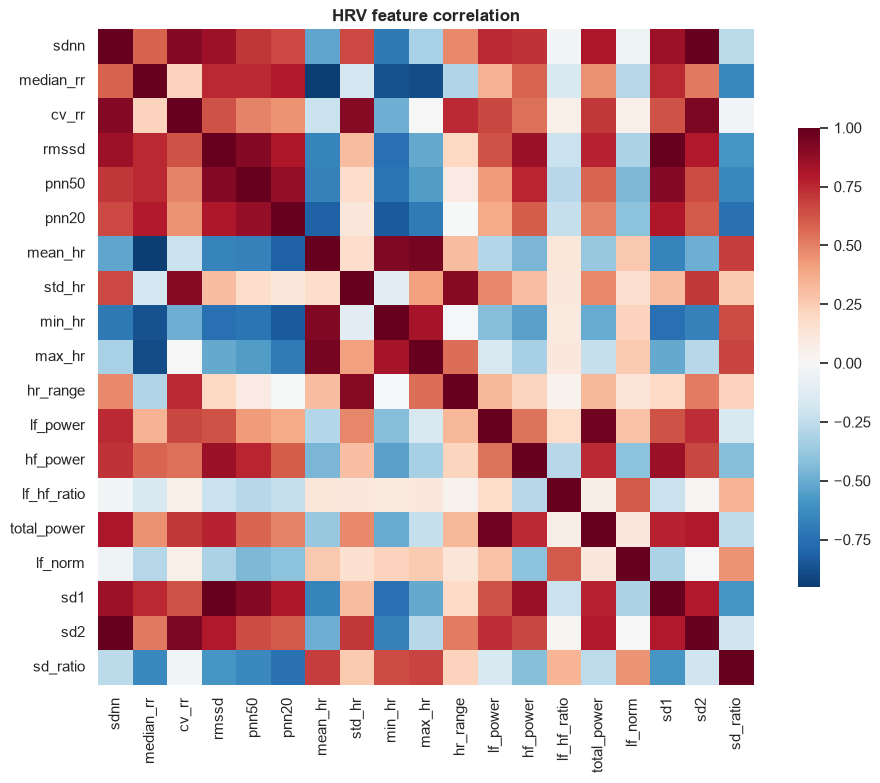

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[list(FEATURES)].corr(), cmap="RdBu_r", center=0, square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("HRV feature correlation", fontweight="bold")
fig.tight_layout()
fig.savefig(OUTPUTS / "feature_correlation.png", dpi=150)